<a href="https://colab.research.google.com/github/ahmadirhamm/Analysis-Exercises/blob/main/Training_dataset_from_kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tahap 1 - Mengambil dataset di kaggle

In [92]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving Viral_Social_Media_Trends.csv to Viral_Social_Media_Trends (1).csv


In [97]:
import os
print(os.listdir('/content'))

['.config', 'drive', 'Viral_Social_Media_Trends (1).csv', 'Viral_Social_Media_Trends.csv', 'sample_data']


In [98]:
data_path = "/content"
file_name = "Viral_Social_Media_Trends.csv"

df = pd.read_csv(os.path.join(data_path, file_name))
df.head()

,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High
1,Post_2,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,Twitter,#Challenge,Video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,YouTube,#Education,Shorts,Australia,917951,127125,11687,36806,Low
4,Post_5,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium


In [101]:
data_path = "/content"
file_name = "Viral_Social_Media_Trends.csv"

df = pd.read_csv(os.path.join(data_path, file_name))
df.head()

,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High
1,Post_2,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,Twitter,#Challenge,Video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,YouTube,#Education,Shorts,Australia,917951,127125,11687,36806,Low
4,Post_5,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium


Tahap 2 - Eksplorasi Data (EDA)
# Info umum dataset

In [102]:
print(df.shape)

(5000, 10)


In [103]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Post_ID           5000 non-null   object
 1   Platform          5000 non-null   object
 2   Hashtag           5000 non-null   object
 3   Content_Type      5000 non-null   object
 4   Region            5000 non-null   object
 5   Views             5000 non-null   int64 
 6   Likes             5000 non-null   int64 
 7   Shares            5000 non-null   int64 
 8   Comments          5000 non-null   int64 
 9   Engagement_Level  5000 non-null   object
dtypes: int64(4), object(6)
memory usage: 390.8+ KB
None


In [104]:
print(df.describe())

              Views          Likes        Shares      Comments
count  5.000000e+03    5000.000000   5000.000000   5000.000000
mean   2.494066e+06  251475.029800  50519.562000  24888.393800
std    1.459490e+06  144349.583384  29066.362671  14284.504319
min    1.266000e+03     490.000000     52.000000     18.000000
25%    1.186207e+06  126892.250000  25029.000000  12305.250000
50%    2.497373e+06  249443.000000  50839.500000  25004.000000
75%    3.759781e+06  373970.750000  75774.250000  37072.750000
max    4.999430e+06  499922.000000  99978.000000  49993.000000


# Cek missing values

In [105]:
print("\nMissing values:")


Missing values:


In [106]:
print(df.isnull().sum())

Post_ID             0
Platform            0
Hashtag             0
Content_Type        0
Region              0
Views               0
Likes               0
Shares              0
Comments            0
Engagement_Level    0
dtype: int64


# Cek distribusi target (Engagment_level)

In [107]:
print("\nDistribusi Engagment Level:")


Distribusi Engagment Level:


In [108]:
print(df['Engagement_Level'].value_counts())

Engagement_Level
Low       1729
High      1673
Medium    1598
Name: count, dtype: int64


Tahap 3 - visualisasi Eksplorasi

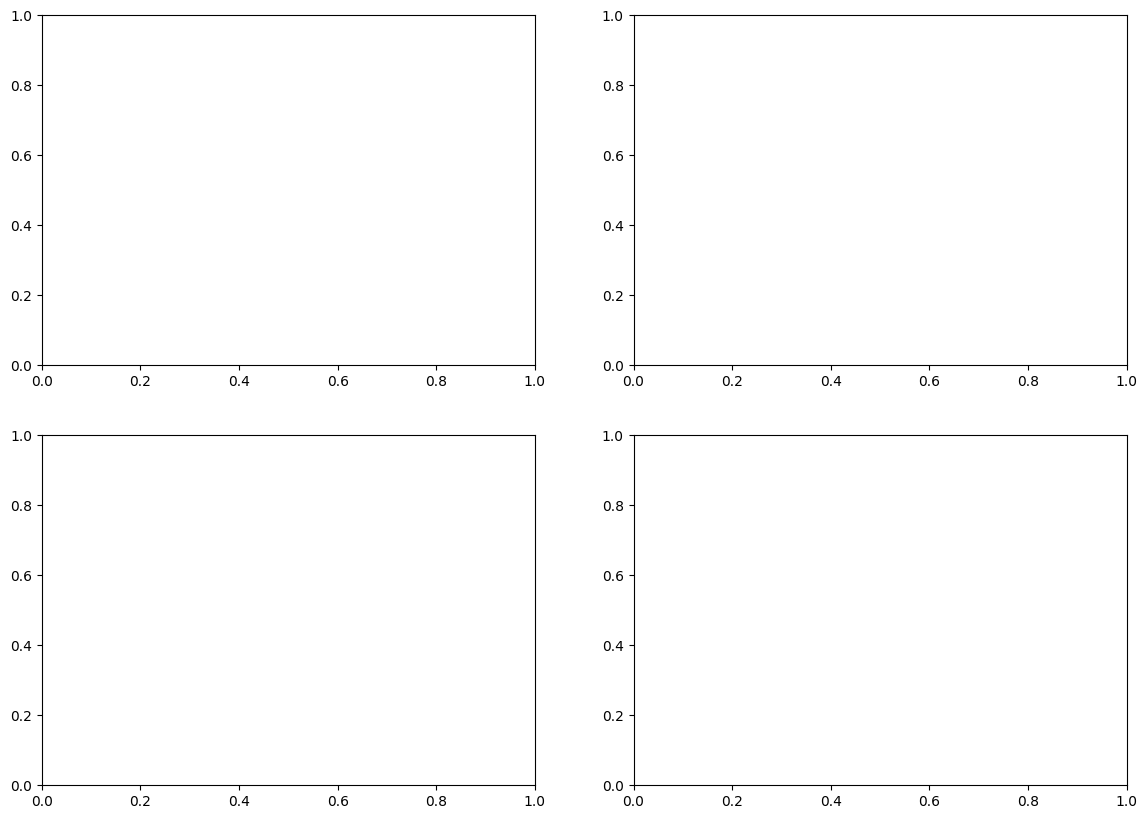

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribusi Engagment Level

In [110]:
df['Engagement_Level'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['#4CAF50','#FF9800','#F44336'])
axes[0, 0].set_title('Distribusi Engagment Level')
axes[0, 0].set_xlabel('')


Text(0.5, 424.44444444444446, '')

# 2. Engagment per Platform

In [111]:
df.groupby('Platform')['Engagement_Level'].value_counts(normalize=True).unstack().plot(
    kind='bar', ax=axes[0,1], colormap='Set2')

<Axes: xlabel='Platform'>

# 3. Rata-rata Views per Region

In [112]:
df.groupby('Region')['Views'].mean().sort_values().plot(kind='barh', ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Rata-rata Views per Region')

Text(0.5, 1.0, 'Rata-rata Views per Region')

# 4. Korelasi fitur numerik




In [113]:
numeric_cols = ['Views', 'Likes', 'Shares', 'Comments']
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', ax=axes[1,1], cmap='coolwarm')
axes[1,1].set_title('Korelasi Fitur Numerik')

Text(0.5, 1.0, 'Korelasi Fitur Numerik')

In [114]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

Full Code Visualisasi Eksplorasi

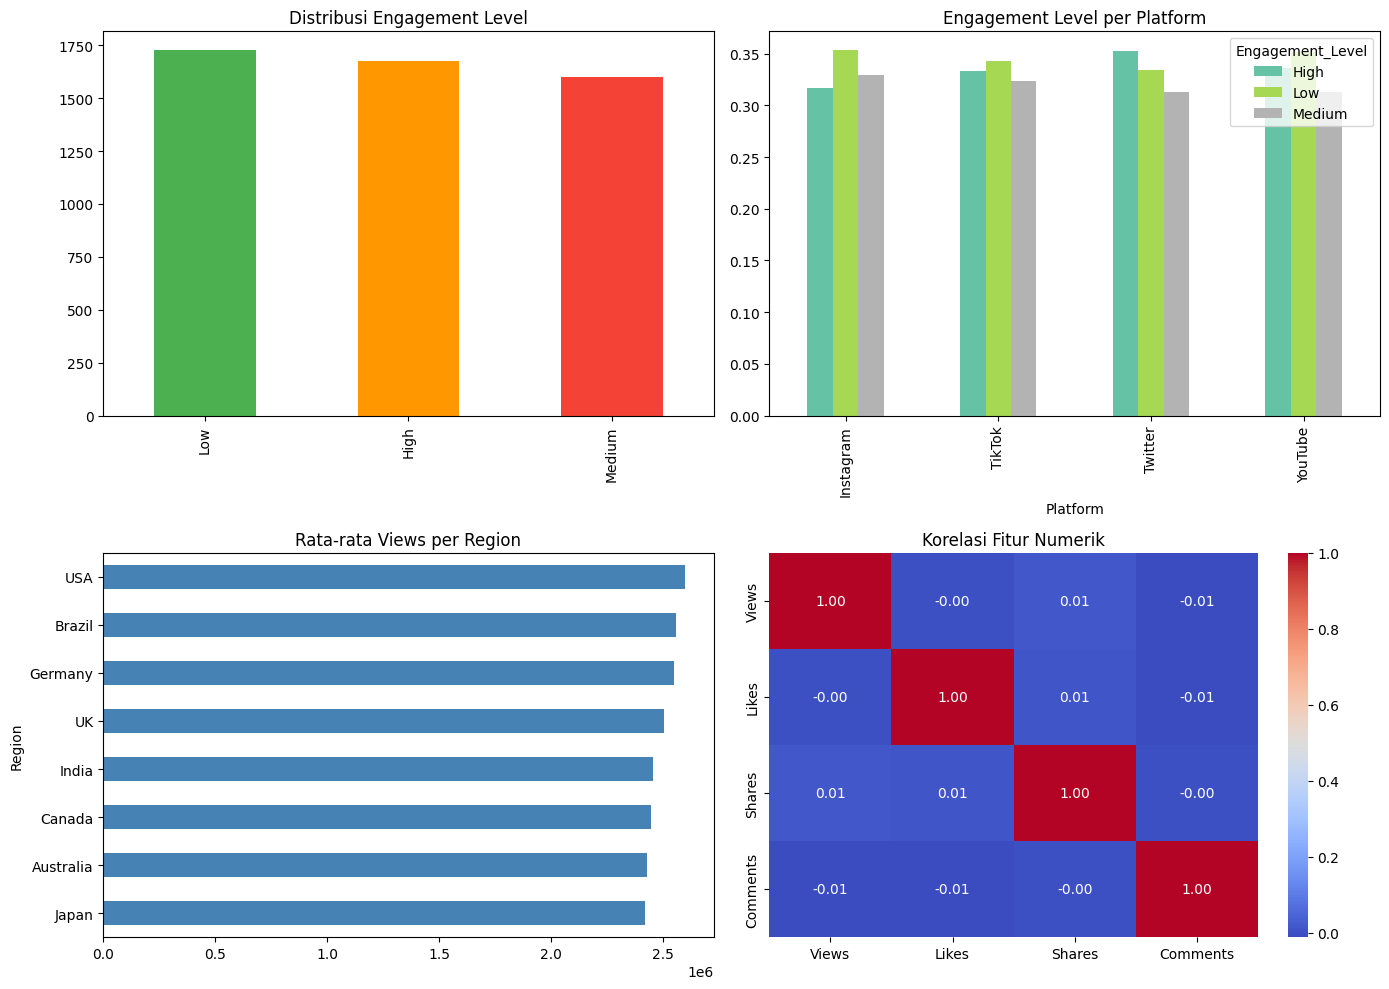

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribusi Engagement Level
df['Engagement_Level'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#4CAF50','#FF9800','#F44336'])
axes[0,0].set_title('Distribusi Engagement Level')
axes[0,0].set_xlabel('')

# 2. Engagement per Platform
df.groupby('Platform')['Engagement_Level'].value_counts(normalize=True).unstack().plot(
    kind='bar', ax=axes[0,1], colormap='Set2')
axes[0,1].set_title('Engagement Level per Platform')

# 3. Rata-rata Views per Region
df.groupby('Region')['Views'].mean().sort_values().plot(kind='barh', ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Rata-rata Views per Region')

# 4. Korelasi fitur numerik
numeric_cols = ['Views','Likes','Shares','Comments']
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', ax=axes[1,1], cmap='coolwarm')
axes[1,1].set_title('Korelasi Fitur Numerik')

plt.tight_layout()
plt.show()

Tahap 4 - PraPemrosesan & Feature Engineering

In [116]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_model = df.copy()

# Hapus kolom ID (tidak informatif)

In [117]:
df_model.drop(columns=['Post_ID'], inplace=True)

Encode kolom kategorikal

In [118]:
cat_cols = ['Platform', 'Hashtag', 'Content_Type', 'Region']
le = LabelEncoder()
for col in cat_cols:
  df_model[col] = le.fit_transform(df_model[col])

# Endcode Target

In [119]:
df_model['Engagement_Level'] = df_model['Engagement_Level'].map({'Low': 0, 'Medium': 1, 'High': 2})

Feature engineering: tambah rasio engagment

In [120]:
df_model['like_rate'] = df_model['Likes'] / (df_model['Views'] + 1)
df_model['comment_rate'] = df_model['Comments'] / (df_model['Views'] + 1)
df_model['share_rate'] = df_model['Shares'] / (df_model['Views'] +1)

print(df_model.head())
print(df_model.dtypes)

   Platform  Hashtag  Content_Type  Region    Views   Likes  Shares  Comments  \
0         1        0             5       6  4163464  339431   53135     19346   
1         0        3             3       4  4155940  215240   65860     27239   
2         2        0             5       1  3666211  327143   39423     36223   
3         3        3             3       0   917951  127125   11687     36806   
4         1        2             1       1    64866  171361   69581      6376   

   Engagement_Level  like_rate  comment_rate  share_rate  
0                 2   0.081526      0.004647    0.012762  
1                 1   0.051791      0.006554    0.015847  
2                 1   0.089232      0.009880    0.010753  
3                 0   0.138488      0.040096    0.012732  
4                 1   2.641728      0.098293    1.072672  
Platform              int64
Hashtag               int64
Content_Type          int64
Region                int64
Views                 int64
Likes              

Tahap 5-Split Data & Scaling

In [121]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_model.drop(columns=['Engagement_Level'])
y = df_model['Engagement_Level']

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (4000, 11), Test: (1000, 11)


Tahap 6-Pelatihan & Perbandingan Model

In [122]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(kernel='rbf', random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, Y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(Y_test, y_pred)
    results[name] = acc
    print(f"\n{'='*40}")
    print(f"Model: {name} | Accuracy: {acc:.4f}")
    print(classification_report(Y_test, y_pred, target_names=['Low','Medium','High']))


Model: Logistic Regression | Accuracy: 0.3470
              precision    recall  f1-score   support

         Low       0.35      0.57      0.44       346
      Medium       0.37      0.14      0.20       320
        High       0.33      0.31      0.32       334

    accuracy                           0.35      1000
   macro avg       0.35      0.34      0.32      1000
weighted avg       0.35      0.35      0.32      1000


Model: Random Forest | Accuracy: 0.3480
              precision    recall  f1-score   support

         Low       0.34      0.39      0.37       346
      Medium       0.36      0.34      0.35       320
        High       0.34      0.31      0.33       334

    accuracy                           0.35      1000
   macro avg       0.35      0.35      0.35      1000
weighted avg       0.35      0.35      0.35      1000


Model: SVM | Accuracy: 0.3700
              precision    recall  f1-score   support

         Low       0.39      0.49      0.43       346
      Medi

✅ Data loaded: (5000, 10)
  Post_ID   Platform     Hashtag Content_Type     Region    Views   Likes  \
0  Post_1     TikTok  #Challenge        Video         UK  4163464  339431   
1  Post_2  Instagram  #Education       Shorts      India  4155940  215240   
2  Post_3    Twitter  #Challenge        Video     Brazil  3666211  327143   
3  Post_4    YouTube  #Education       Shorts  Australia   917951  127125   
4  Post_5     TikTok      #Dance         Post     Brazil    64866  171361   

   Shares  Comments Engagement_Level  
0   53135     19346             High  
1   65860     27239           Medium  
2   39423     36223           Medium  
3   11687     36806              Low  
4   69581      6376           Medium  
✅ Preprocessing selesai
✅ Split selesai — Train: (4000, 11), Test: (1000, 11)
  Logistic Regression: 0.3470
  Random Forest: 0.3520
  SVM: 0.3700
  Gradient Boosting: 0.3410
✅ Training selesai

📊 Classification Report — SVM:
              precision    recall  f1-score   suppor

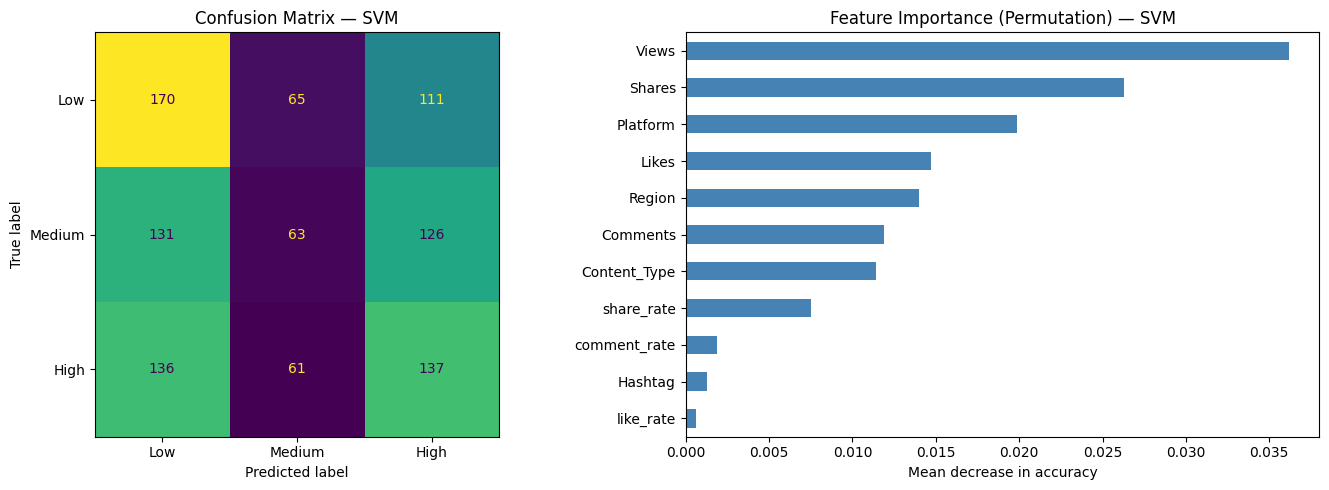

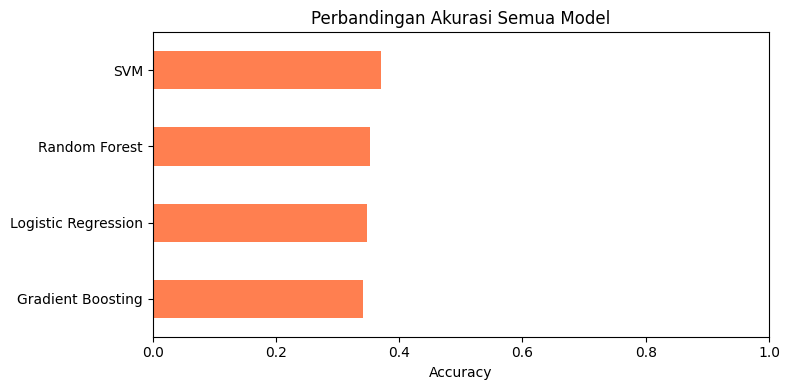

✅ Semua tahap selesai!


In [126]:
# ════════════════════════════════════════════
# IMPORT
# ════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

# ════════════════════════════════════════════
# TAHAP 1 — LOAD DATA
# ════════════════════════════════════════════
df = pd.read_csv("/content/Viral_Social_Media_Trends.csv")
print("✅ Data loaded:", df.shape)
print(df.head())

# ════════════════════════════════════════════
# TAHAP 2 — PREPROCESSING
# ════════════════════════════════════════════
df_model = df.copy()
df_model.drop(columns=['Post_ID'], inplace=True)

cat_cols = ['Platform', 'Hashtag', 'Content_Type', 'Region']
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

df_model['Engagement_Level'] = df_model['Engagement_Level'].map(
    {'Low': 0, 'Medium': 1, 'High': 2}
)

df_model['like_rate']    = df_model['Likes']    / (df_model['Views'] + 1)
df_model['share_rate']   = df_model['Shares']   / (df_model['Views'] + 1)
df_model['comment_rate'] = df_model['Comments'] / (df_model['Views'] + 1)

print("✅ Preprocessing selesai")

# ════════════════════════════════════════════
# TAHAP 3 — SPLIT & SCALE
# ════════════════════════════════════════════
X = df_model.drop(columns=['Engagement_Level'])
y = df_model['Engagement_Level']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✅ Split selesai — Train: {X_train.shape}, Test: {X_test.shape}")

# ════════════════════════════════════════════
# TAHAP 4 — TRAINING SEMUA MODEL
# ════════════════════════════════════════════
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(kernel='rbf', random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = accuracy_score(y_test, y_pred)
    print(f"  {name}: {results[name]:.4f}")

print("✅ Training selesai")

# ════════════════════════════════════════════
# TAHAP 5 — EVALUASI SVM
# ════════════════════════════════════════════
best_model  = models['SVM']
y_pred_best = best_model.predict(X_test_scaled)

print("\n📊 Classification Report — SVM:")
print(classification_report(y_test, y_pred_best,
      target_names=['Low', 'Medium', 'High']))

# ════════════════════════════════════════════
# TAHAP 6 — CONFUSION MATRIX & FEATURE IMPORTANCE
# ════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=['Low','Medium','High']).plot(
    ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — SVM')

# Permutation Importance
print("\n⏳ Menghitung permutation importance, tunggu sebentar...")
perm = permutation_importance(
    best_model, X_test_scaled, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)
feat_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values()
feat_imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance (Permutation) — SVM')
axes[1].set_xlabel('Mean decrease in accuracy')

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════
# TAHAP 7 — PERBANDINGAN SEMUA MODEL
# ════════════════════════════════════════════
pd.Series(results).sort_values().plot(kind='barh', color='coral', figsize=(8, 4))
plt.title('Perbandingan Akurasi Semua Model')
plt.xlabel('Accuracy')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print("✅ Semua tahap selesai!")

Tahap 7 - Evaluasi Visual & Feature Importance

NameError: name 'y_test' is not defined

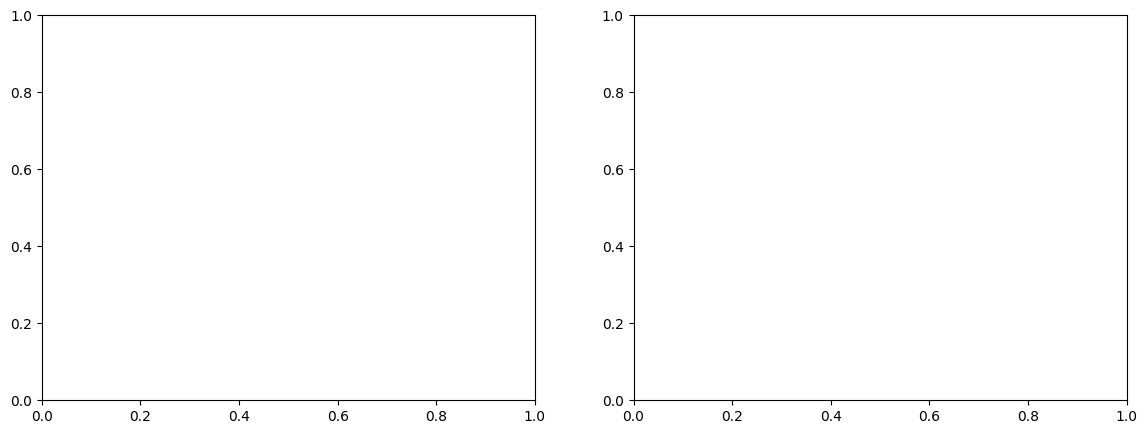

In [125]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

best_model = models['SVM']
y_pred_best = best_model.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=['Low','Medium','High']).plot(
    ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — SVM')

# --- Permutation Importance (works for ALL models) ---
perm = permutation_importance(
    best_model, X_test_scaled, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1        # pakai semua CPU core, lebih cepat
)

feat_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values()
feat_imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance (Permutation) — SVM')
axes[1].set_xlabel('Mean decrease in accuracy')

plt.tight_layout()
plt.show()